**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)    
- [合成数据生成（KNN插值版）](#toc9_)    
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[文件说明（File descriptions）](#toc0_)
- train.csv - 提取自日本 NIMS 数据库，包含 21000 多种超导材料的 81 个连续数值特征



# <a id='toc2_'></a>[数据字段（Data fields）](#toc0_)

- number_of_elements：化合物中的元素种类数
- mean_atomic_mass：原子量平均值
- wtd_mean_atomic_mass：加权平均原子量
- gmean_atomic_mass：原子量几何平均
- wtd_gmean_atomic_mass：加权几何平均原子量
- entropy_atomic_mass：原子量熵
- wtd_entropy_atomic_mass：加权原子量熵
- range_atomic_mass：原子量极差
- wtd_range_atomic_mass：加权原子量极差
- std_atomic_mass：原子量标准差
- wtd_std_atomic_mass：加权原子量标准差
- mean_fie…wtd_std_fie：第一电离能相关统计
- mean_atomic_radius…wtd_std_atomic_radius：原子半径相关统计
- mean_Density…wtd_std_Density：密度相关统计
- mean_ElectronAffinity…wtd_std_ElectronAffinity：电子亲和能相关统计
- mean_FusionHeat…wtd_std_FusionHeat：熔化热相关统计
- mean_ThermalConductivity…wtd_std_ThermalConductivity：热导率相关统计
- mean_Valence…wtd_std_Valence：价电子数相关统计

- **critical_temp**：临界温度（超导临界温度，**二分类任务的标签**）

# <a id='toc3_'></a>[导入库](#toc0_)

In [2]:
# ==========================================
# 高温超导体预测（LightGBM + XGBoost + CatBoost）
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 数据合成
# 3. 五折 StratifiedKFold 训练
# 4. 加权融合 + Stacking
# 5. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & finXont 报错
# ----------------------------
import matplotlib as mpl

# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "SimHei",                # 万一你后来自己装了 SimHei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

In [3]:
TRAIN_PATH = "train.csv"
LABEL = 'is_superconductor'  # 标签名
LABEL_DESC = 'Is_superconductor'  # 标签描述（在可视化中描述比较抽象的标签名，比如 Target 等）

In [4]:
# ------------------------------------------------------------------
# Paper figures export (WHITELIST)
# 仅将白名单中的论文图表额外保存到 paper_figs/，其余一律不保存到该目录
# ------------------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
PAPER_FIG_DIR = "paper_figs"  # 论文图表保存目录
EXP_FIG_DIR = "exp_figs"  # 普通实验图表保存目录
os.makedirs(PAPER_FIG_DIR, exist_ok=True)
os.makedirs(EXP_FIG_DIR, exist_ok=True)

# 白名单：仅保留论文中除 Fig.1 之外提到的图表/表格
PAPER_WHITELIST = {
    # Figures (paper)
    "fig2_corr_heatmap.png",
    "fig3_shap_bar.png",
    "fig4_shap_summary.png",
    "fig5_shap_dependence.png",
    "shap_dependence_interest_rate.png",
    "shap_dependence_annual_income.png",
    "roc_pr_all_models.png",
    # Tables (paper)
    "table2_model_metrics.csv",
}

def save_paper_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
    """Save current matplotlib figure to paper_figs/ ONLY if filename is in PAPER_WHITELIST."""
    if filename in PAPER_WHITELIST:
        plt.savefig(os.path.join(PAPER_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)

def save_paper_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
    """Save dataframe to paper_figs/ ONLY if filename is in PAPER_WHITELIST."""
    if filename in PAPER_WHITELIST:
        X.to_csv(os.path.join(PAPER_FIG_DIR, filename), **to_csv_kwargs)

def save_exp_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight"):
    """Save current matplotlib figure to exp_figs."""
    plt.savefig(os.path.join(EXP_FIG_DIR, filename), dpi=dpi, bbox_inches=bbox_inches)

def save_exp_csv(X: pd.DataFrame, filename: str, **to_csv_kwargs):
    """Save dataframe to exp_figs."""
    path = os.path.join(EXP_FIG_DIR, filename)
    X.to_csv(path, **to_csv_kwargs)
    print(f'>>> 已保存: {path}')

print(">>> paper_figs 白名单已启用：")
pprint(sorted(PAPER_WHITELIST))

>>> paper_figs 白名单已启用：
['fig2_corr_heatmap.png',
 'fig3_shap_bar.png',
 'fig4_shap_summary.png',
 'fig5_shap_dependence.png',
 'roc_pr_all_models.png',
 'shap_dependence_annual_income.png',
 'shap_dependence_interest_rate.png',
 'table2_model_metrics.csv']


# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [42]:
train = pd.read_csv(TRAIN_PATH)
sz = int(len(train) * 0.25)
train[LABEL] = (train['critical_temp'] >= 77).astype(int)
train = train.drop(columns=['critical_temp'])
train = train[:sz].reset_index(drop=True)
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,is_superconductor
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,0


In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5315 entries, 0 to 5314
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               5315 non-null   int64  
 1   mean_atomic_mass                 5315 non-null   float64
 2   wtd_mean_atomic_mass             5315 non-null   float64
 3   gmean_atomic_mass                5315 non-null   float64
 4   wtd_gmean_atomic_mass            5315 non-null   float64
 5   entropy_atomic_mass              5315 non-null   float64
 6   wtd_entropy_atomic_mass          5315 non-null   float64
 7   range_atomic_mass                5315 non-null   float64
 8   wtd_range_atomic_mass            5315 non-null   float64
 9   std_atomic_mass                  5315 non-null   float64
 10  wtd_std_atomic_mass              5315 non-null   float64
 11  mean_fie                         5315 non-null   float64
 12  wtd_mean_fie        

In [44]:
print(train.isnull().sum()) #checking for total null values

number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
is_superconductor        0
Length: 82, dtype: int64


In [45]:
label_map_int2str = {0 : 'No', 1 : 'Yes'}
train[LABEL_DESC] = train[LABEL].map(label_map_int2str)

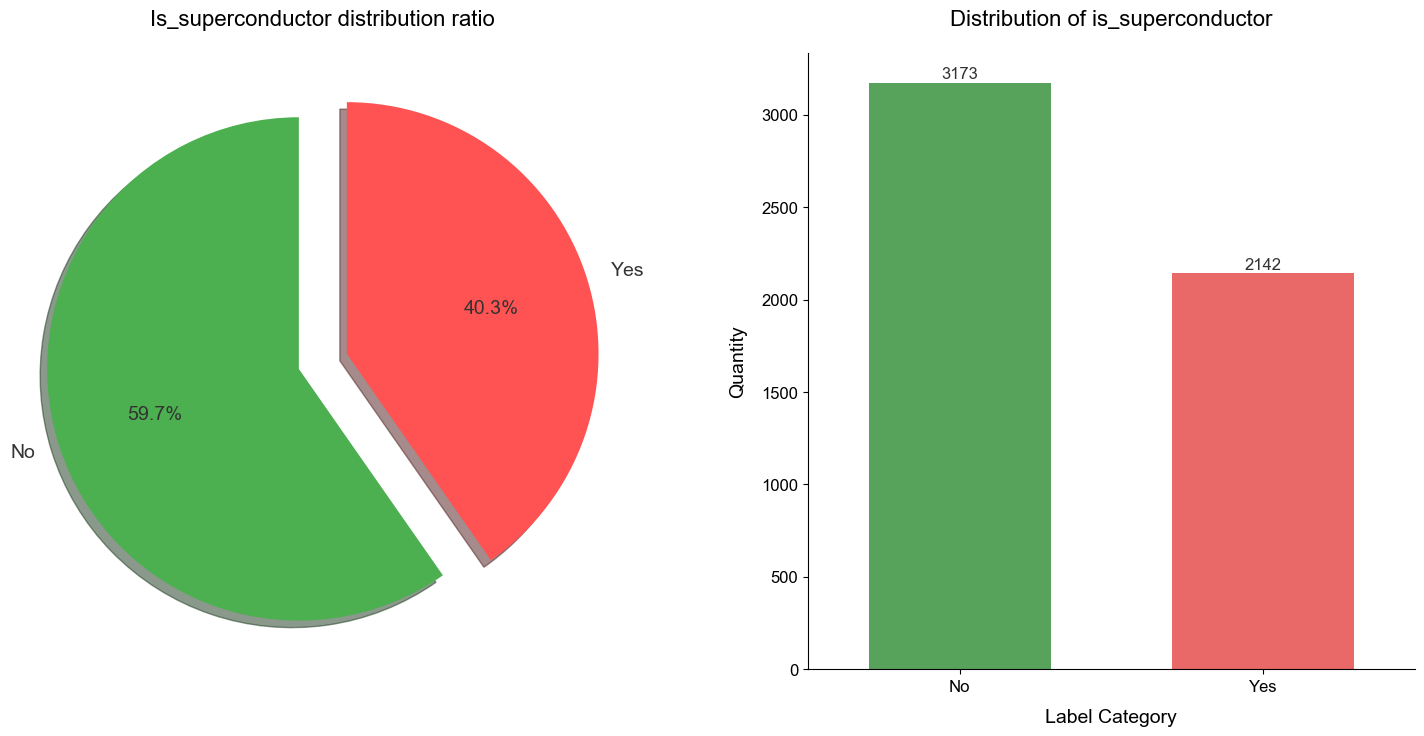

In [46]:
from utils import plot_label_distribution

plot_label_distribution(
    df=train, label_desc=LABEL_DESC,
    # pie_title=f'{LABEL_DESC} distribution ratio'.capitalize(),
    # bar_title=f'distribution of {LABEL_DESC}'.capitalize(),
)

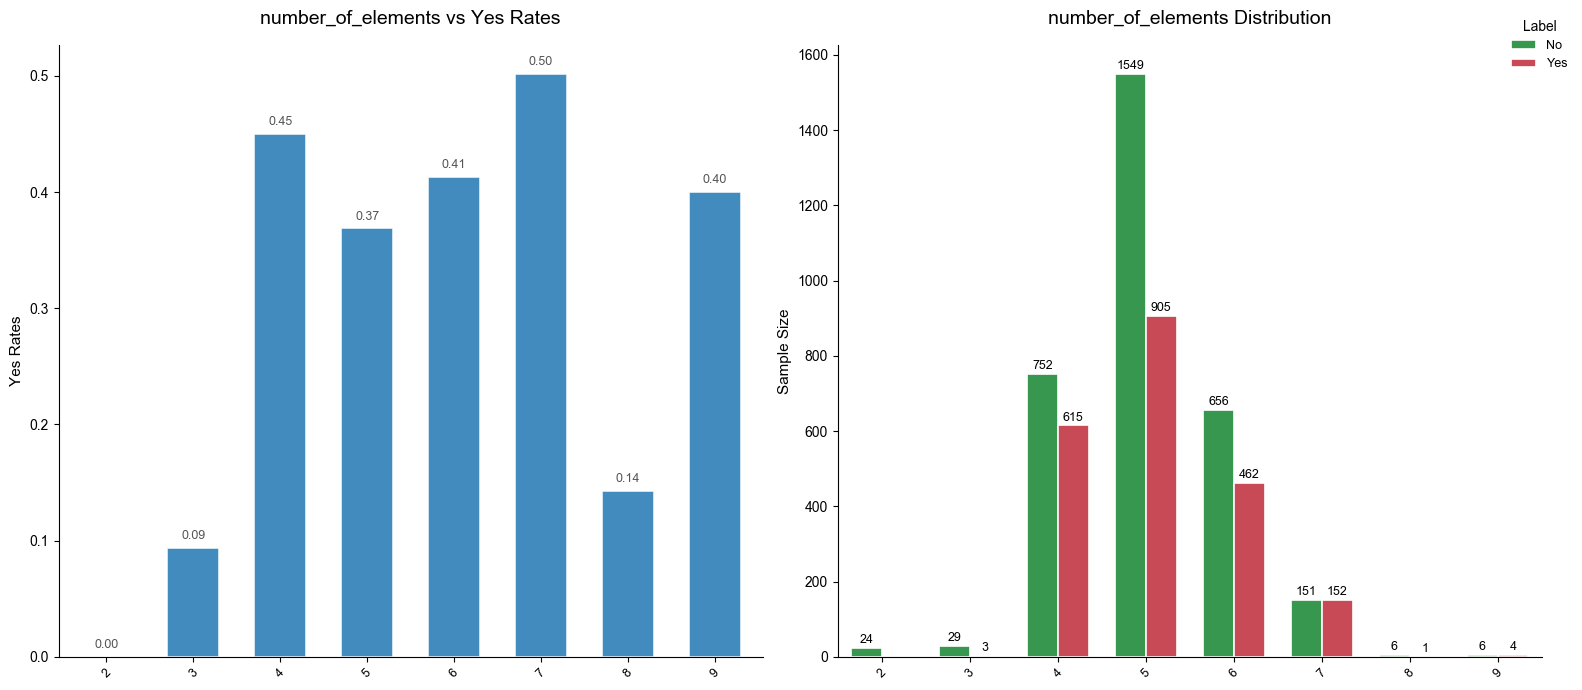

In [47]:
from utils import plot_discrete_variable_label_relationship

discrete_variables = ['number_of_elements']
# variables = ['Substrate_Type', 'Deposition_Method', 'Material_Type']
for var in discrete_variables:
    plot_discrete_variable_label_relationship(
        df=train,
        var=var,
        label=LABEL,
        label_desc=LABEL_DESC,
    )

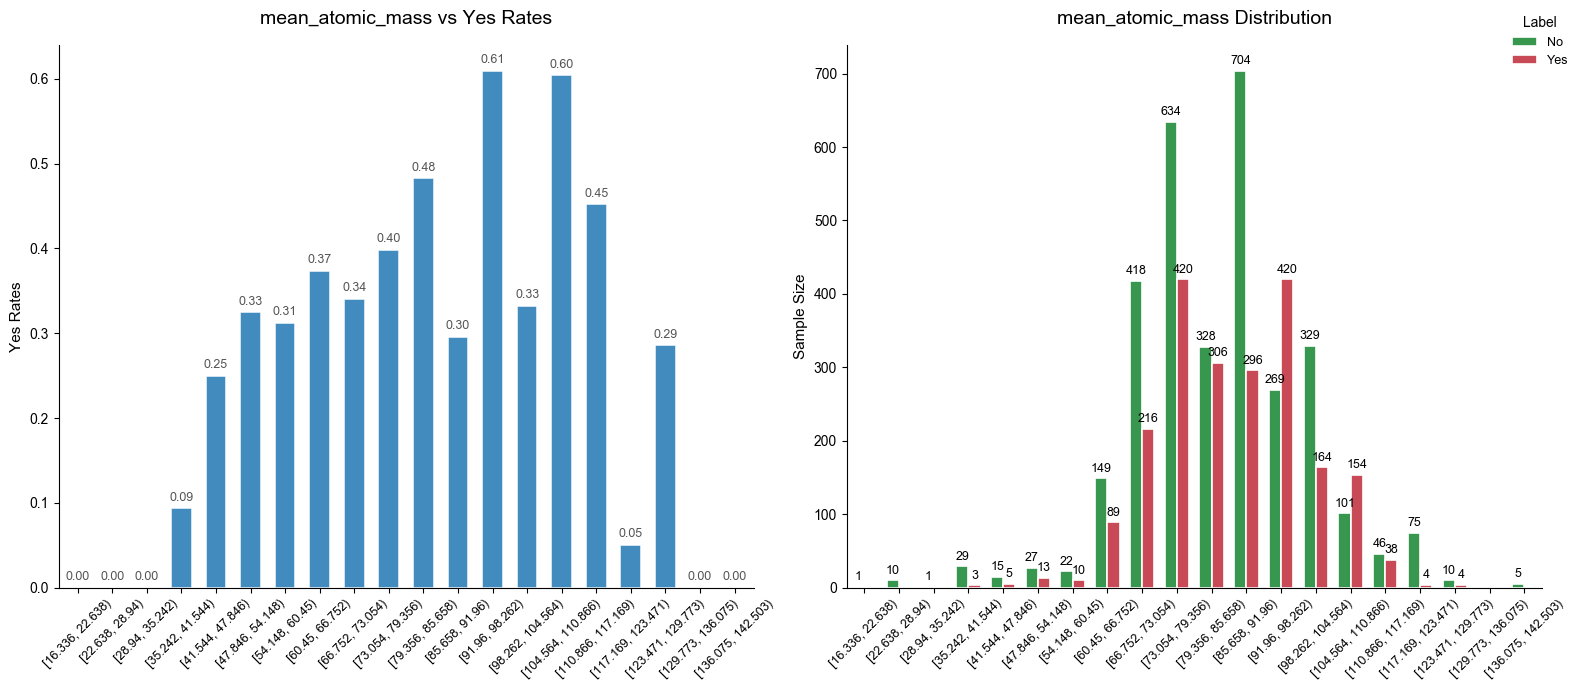

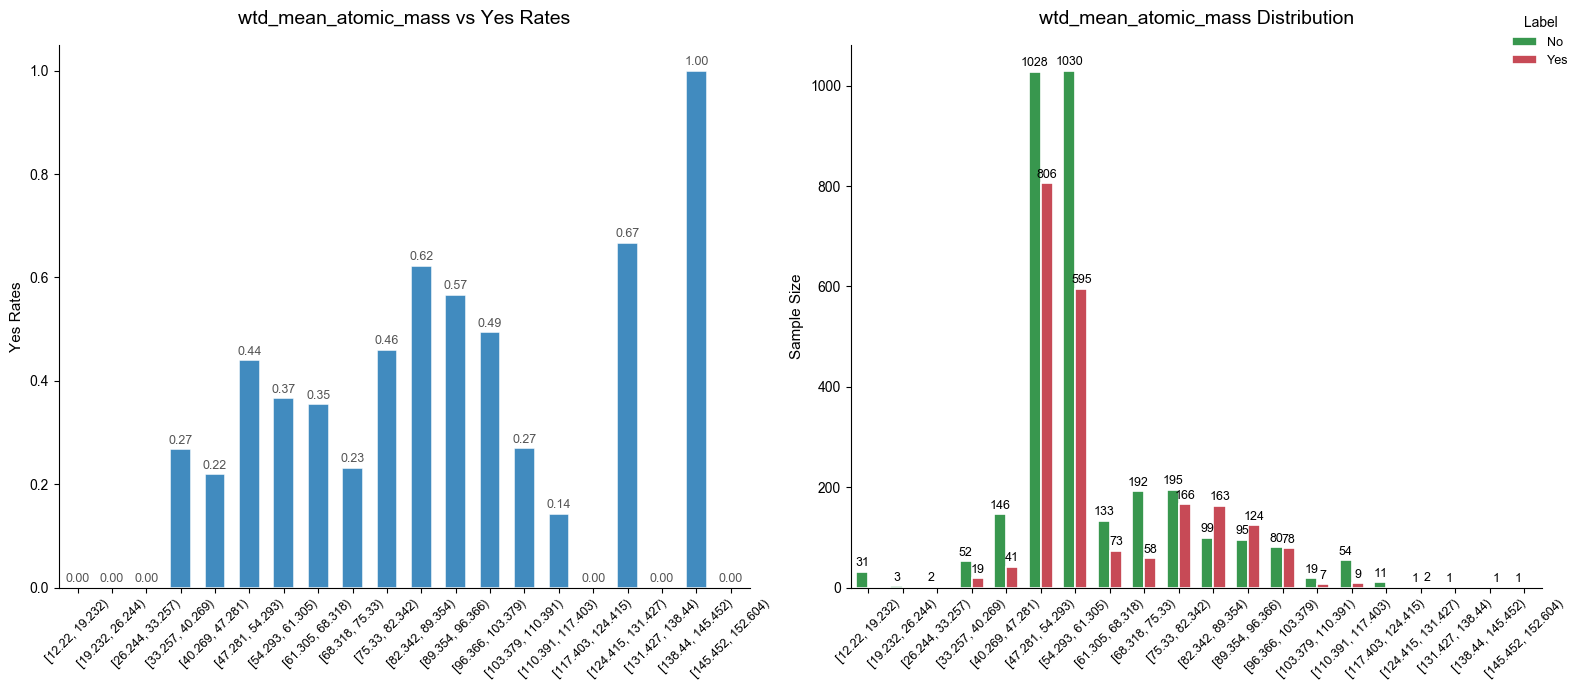

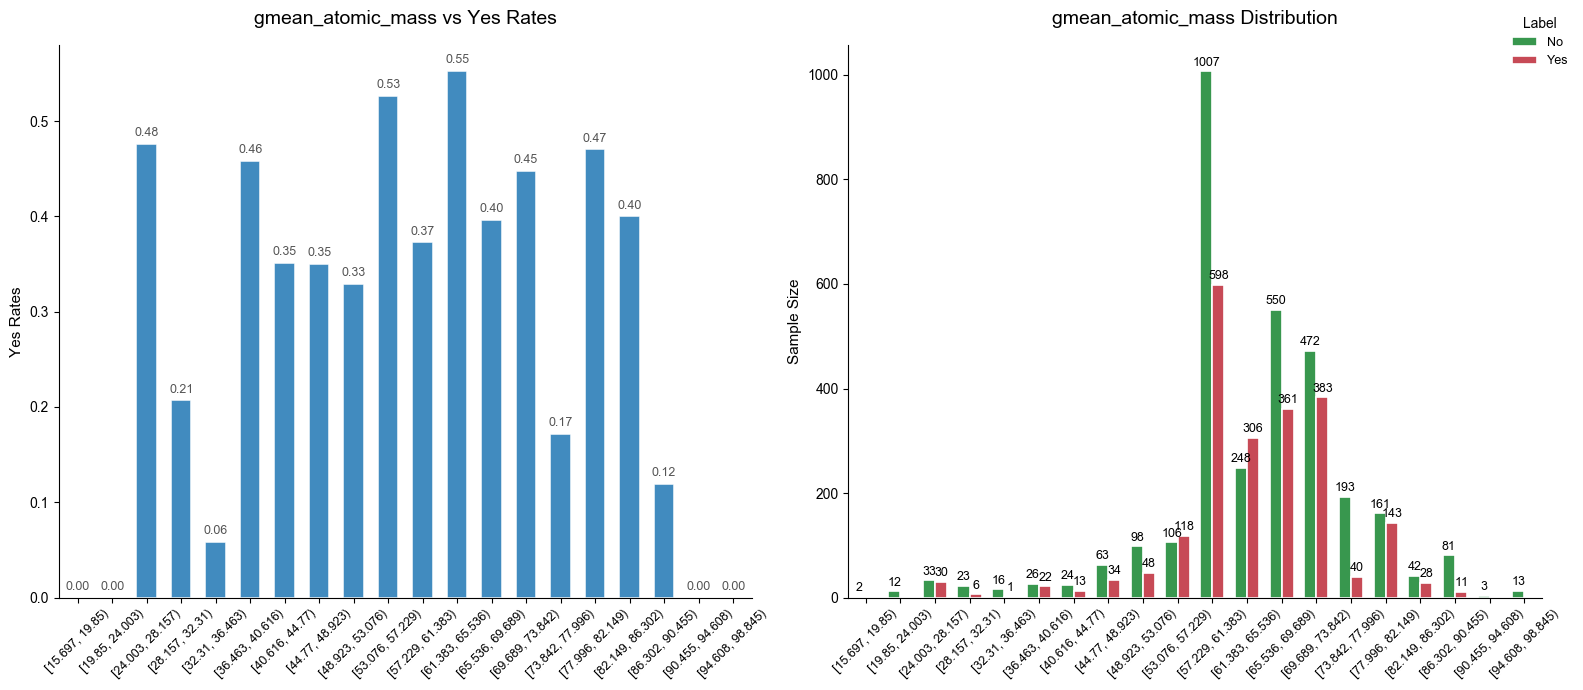

In [48]:
from utils import plot_continuous_variable_label_relationship

continuous_variables = [
    'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass' 
]
for var in continuous_variables:
    plot_continuous_variable_label_relationship(
        df=train,
        var=var,
        label=LABEL,
        label_desc=LABEL_DESC,
        bins=20,
        names=None,
    )

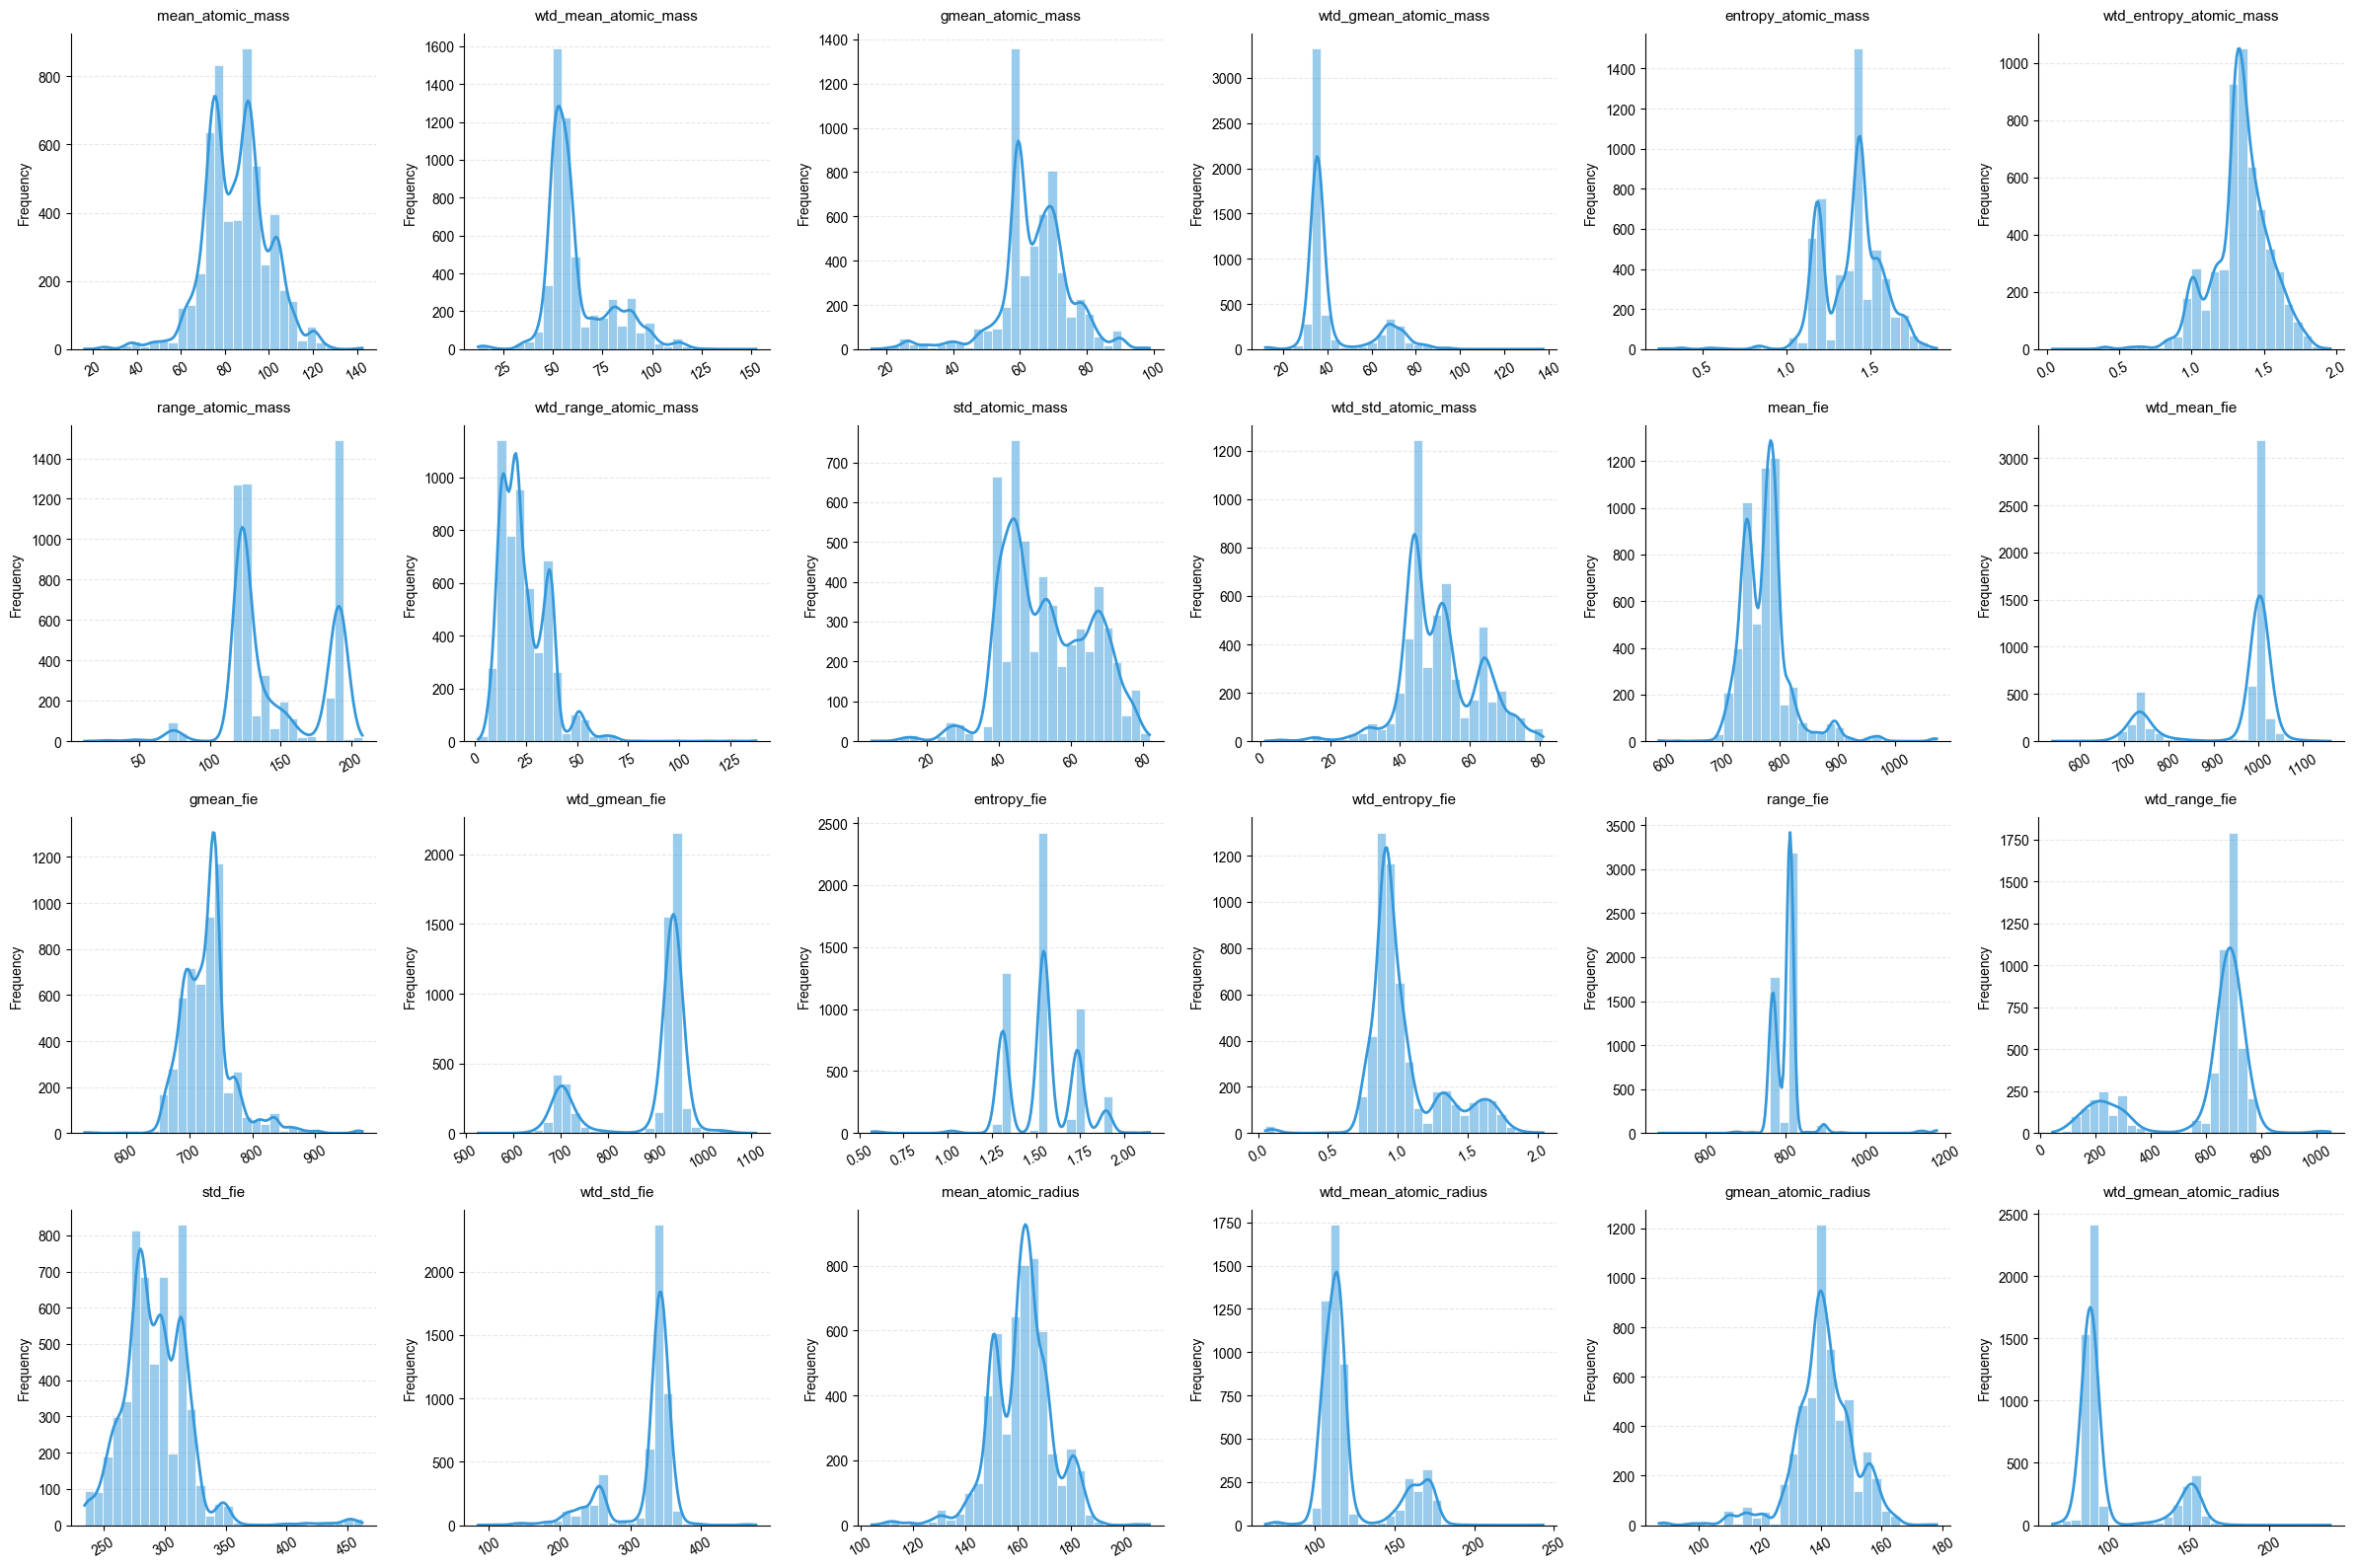

In [49]:
from utils import plot_variables_distribution

# 主要特征
NUM_FEATURE_NAMES = ['mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',]
plot_variables_distribution(
    df=train,
    variables=NUM_FEATURE_NAMES,
)

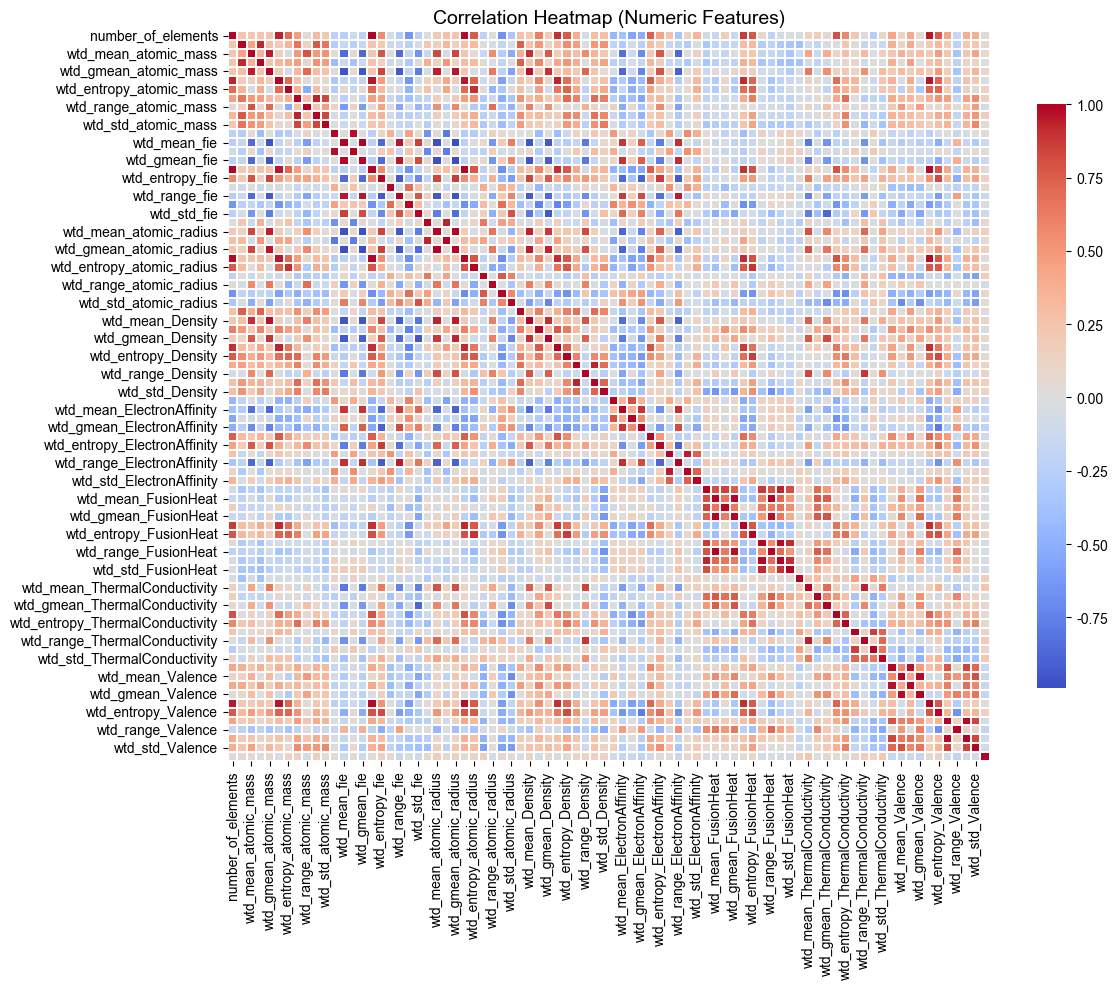

In [50]:
# ------------------------------------------------------------------
# Figure (Paper-like): Correlation Heatmap (Numeric Features)
# ------------------------------------------------------------------
from utils import plot_heatmap

plot_heatmap(train)
save_paper_figure('fig2_corr_heatmap.png', dpi=300, bbox_inches='tight')


# <a id='toc6_'></a>[数据预处理](#toc0_)


功能：处理数据中不规范列名与字符串，处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备

In [51]:
class DataPreprocessing:
    def __init__(self):
        pass

    def fit(self, X):
        pass

    def transform(self, X):
        """对数据进行清洗转换：处理异常值、填充缺失值、添加标记列"""
        # 复制输入数据，避免修改原始数据
        X = X.copy()
        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

1. 晶格畸变与结构不稳定性
算晶格尺寸变异系数，为加权原子半径标准差除以加权原子半径均值；算价电子涨落指数，为加权价电子标准差除以加权价电子均值。

2. 电子结构与成键特性
算Mulliken电负性代理，为加权电离能均值加加权电子亲和能均值除以2；算绝对化学硬度，为加权电离能均值减加权电子亲和能均值除以2；算掺杂主元偏移度，为加权原子质量均值减原子质量算术均值。

3. 热力学与声子特征
算热传导-熔化耦合比，为加权热导率均值除以加权熔化热均值；算摩尔堆积密度，为加权密度均值除以加权原子质量均值；算质量-声子关联振荡，为1除以加权原子质量均值的平方根。

4. 复杂性与熵效应
算绝对构型熵容差，为元素数量乘以原子质量熵；算电离能跨度比，为电离能范围除以加权电离能均值。

In [52]:
class FeatureGenerator:
    """特征生成器类，用于对输入数据进行特征工程处理，生成模型所需的特征"""
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据
            
        返回:
            pandas.DataFrame，处理后的特征数据
        """
        # 复制输入数据，避免修改原始数据
        df_features = X.copy()
        epsilon = 1e-6  # 防止除以零
    
        # ==========================================
        # 1. 晶格畸变与结构不稳定性
        # ==========================================
        # 尺寸变异系数 (衡量晶格畸变)
        df_features['Lattice_Size_Mismatch'] = df_features['wtd_std_atomic_radius'] / (df_features['wtd_mean_atomic_radius'] + epsilon)
        
        # 价电子涨落指数
        df_features['Valence_Fluctuation_Index'] = df_features['wtd_std_Valence'] / (df_features['wtd_mean_Valence'] + epsilon)
        
        # ==========================================
        # 2. 电子结构与成键特性
        # ==========================================
        # Mulliken 电负性代理
        df_features['Mulliken_Electronegativity_Proxy'] = (df_features['wtd_mean_fie'] + df_features['wtd_mean_ElectronAffinity']) / 2.0
        
        # 绝对化学硬度
        df_features['Chemical_Hardness_Proxy'] = (df_features['wtd_mean_fie'] - df_features['wtd_mean_ElectronAffinity']) / 2.0
        
        # 掺杂主元偏移度 (加权均值与算术均值的差异，反映浓度偏斜)
        df_features['Stoichiometric_Mass_Shift'] = df_features['wtd_mean_atomic_mass'] - df_features['mean_atomic_mass']

        # ==========================================
        # 3. 热力学与声子特征
        # ==========================================
        # 热传导-熔化耦合比
        df_features['Thermal_Fusion_Coupling'] = df_features['wtd_mean_ThermalConductivity'] / (df_features['wtd_mean_FusionHeat'] + epsilon)
        
        # 摩尔堆积密度 (密度 / 质量)
        df_features['Molar_Packing_Density'] = df_features['wtd_mean_Density'] / (df_features['wtd_mean_atomic_mass'] + epsilon)
        
        # 质量-声子关联振荡 (经典的超导同位素效应公式 Tc ~ M^(-1/2))
        df_features['Mass_Phonon_Oscillation'] = 1.0 / np.sqrt(df_features['wtd_mean_atomic_mass'] + epsilon)

        # ==========================================
        # 4. 复杂性与熵效应
        # ==========================================
        # 绝对构型熵容差
        df_features['Absolute_Configurational_Entropy'] = df_features['number_of_elements'] * df_features['entropy_atomic_mass']
        
        # 电离能跨度比
        df_features['Ionization_Energy_Range_Ratio'] = df_features['range_fie'] / (df_features['wtd_mean_fie'] + epsilon)
        
        # 返回处理后的特征数据
        return df_features

1. 从训练数据中分离目标变量（转为整数）和特征数据，复制测试数据。
2. 用训练特征拟合预处理模型，再分别对训练和测试特征做预处理。
3. 通过特征生成器对预处理后的训练、测试特征进行特征工程，确保处理一致性，为建模做准备。

In [53]:
train_X, test_X, train_y, test_y = train_test_split(
    train.drop(columns=[LABEL, LABEL_DESC]), # drop LABEL LABEL_DESC
    train[LABEL],
    test_size=0.2, random_state=42,
)

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)

1. 精准划分特征类型
2. 为不同特征类型构建专属处理管道
3. 整合列转换器与应用完整处理流程

In [54]:
def clean_feature_names(columns):
    new_columns = []
    for col in columns:
        # 1. 替换特殊字符 (括号, &, %, 逗号) 为下划线
        new_col = re.sub(r'[(),&%\s:-]+', '_', col)
        # 2. 去除首尾可能的下划线
        new_col = new_col.strip('_')
        new_columns.append(new_col)

    return new_columns

In [55]:
from utils import construct_process_pipeline

# 划分类别型特征列：筛选数据类型为object的列（通常为字符串类型的类别特征）
cat_cols = [c for c in train_fe.columns if train_fe[c].dtype == 'object']

# 划分数值型特征列：除类别特征外的其他列（通常为int/float类型的连续或离散数值特征）
num_cols = [c for c in train_fe.columns if c not in cat_cols]

# 构建预处理流程管道
preprocess = construct_process_pipeline(num_cols, cat_cols)

# 用训练集拟合完整的预处理流程（学习数值特征的中位数、类别特征的众数和编码规则等）
# 并对训练特征数据进行最终转换，得到可直接输入模型的特征矩阵
X_train = preprocess.fit_transform(train_fe)
columns = clean_feature_names(preprocess.get_feature_names_out())  # 处理特征名称中的违规符号
X_train = pd.DataFrame(X_train, columns=columns)

# 用拟合好的预处理流程转换测试特征数据（保证与训练集处理逻辑完全一致）
X_test = preprocess.transform(test_fe)
X_test = pd.DataFrame(X_test, columns=columns)

In [56]:
X_train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Lattice_Size_Mismatch,Valence_Fluctuation_Index,Mulliken_Electronegativity_Proxy,Chemical_Hardness_Proxy,Stoichiometric_Mass_Shift,Thermal_Fusion_Coupling,Molar_Packing_Density,Mass_Phonon_Oscillation,Absolute_Configurational_Entropy,Ionization_Energy_Range_Ratio
0,5.0,72.952854,57.168210,59.186241,35.887295,1.445795,0.951781,122.90607,37.619066,40.250192,...,0.641541,0.195778,561.774357,449.697357,-15.784644,15.866869,52.240812,0.132258,7.228973,0.763244
1,7.0,90.290589,64.980275,70.219728,40.062558,1.737042,1.648861,192.98100,24.870113,58.788550,...,0.606849,0.545826,562.554531,444.276719,-25.310314,11.917245,48.767137,0.124054,12.159297,0.758916
2,5.0,105.454280,61.266129,80.441567,36.973124,1.431855,1.294521,141.25060,30.076714,55.962907,...,0.715419,0.219159,563.376500,450.105071,-44.188151,13.714357,55.360339,0.127758,7.159276,0.762717
3,5.0,66.551958,51.105033,50.697784,34.820356,1.383686,1.304048,121.32760,21.023456,43.907216,...,0.692213,0.130952,555.927500,447.050192,-15.446925,18.271873,57.301299,0.139884,6.918431,0.808193
4,5.0,88.679574,57.169504,70.154267,35.889903,1.445332,0.989385,122.90607,36.716369,46.485352,...,0.643811,0.195269,561.655482,449.690946,-31.510070,15.985941,52.076254,0.132257,7.226660,0.801506


# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [57]:
# ------------------------------------------------------------------
# 小样本快速优化（用 3 折 & 700 样本）
# ------------------------------------------------------------------
train_size = 800 if X_train.shape[0] > 800 else int(X_train.shape[0] * 0.8)
sample_idx, _ = train_test_split(
    np.arange(X_train.shape[0]), stratify=train_y, train_size=train_size, random_state=42
)
X_sample, y_sample = X_train.iloc[sample_idx], train_y.iloc[sample_idx]

class_weight = len(train_y) / (2 * np.bincount(train_y))  # 类别权重
xgb_scale_weight = class_weight[1] / class_weight[0] if 'class_weight' in locals() else 1.0

In [58]:
from utils import (
    bayes_opt_serial, bayes_opt, TunedMLP,
    lr_space, svc_space, dt_space, rf_space,
    gbdt_space, nb_space, mlp_space,
    lgb_space, xgb_space, cat_space,
)

# ================= 基础模型 (Sklearn) =================
print('【逻辑回归 (LR) 贝叶斯优化】')
model = LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
lr_model, lr_best = bayes_opt(model, lr_space, X_sample, y_sample, n_iter=12)

print('【支持向量机 (SVM) 贝叶斯优化】')
# SVM 训练较慢，probability=True 会更慢，但在小样本(800)下可接受
model = SVC(probability=False, class_weight='balanced', random_state=42)
svm_model, svm_best = bayes_opt(model, svc_space, X_sample, y_sample, n_iter=1)

print('【决策树 (DT) 贝叶斯优化】')
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model, dt_best = bayes_opt(model, dt_space, X_sample, y_sample, n_iter=12)

print('【随机森林 (RF) 贝叶斯优化】')
model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model, rf_best = bayes_opt(model, rf_space, X_sample, y_sample, n_iter=12)

print('【GBDT (Sklearn) 贝叶斯优化】')
# Sklearn GBDT 原生不支持 class_weight 参数，通常需手动处理样本权重或忽略
model = GradientBoostingClassifier(random_state=42)
gbdt_model, gbdt_best = bayes_opt(model, gbdt_space, X_sample, y_sample, n_iter=12)

print('【朴素贝叶斯 (NB) 贝叶斯优化】')
model =  GaussianNB()
nb_model, nb_best = bayes_opt(model, nb_space, X_sample, y_sample, n_iter=12)

print('【MLP (神经网络) 贝叶斯优化】')
model = TunedMLP(max_iter=1000, early_stopping=True, random_state=42)
mlp_model, mlp_best = bayes_opt_serial(model, mlp_space, X_sample, y_sample, n_iter=12)
mlp_best = dict(mlp_best)
best_idx = int(mlp_best.pop('layer_idx')) # 移除 layer_idx
mlp_best['hidden_layer_sizes'] = [(50,), (100,), (50, 50)][best_idx] # 加回 hidden_layer_sizes

# ================= 提升树模型 (Boosting) =================
print('【LightGBM 贝叶斯优化】')
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgb_model, lgb_best = bayes_opt(model, lgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【XGBoost 贝叶斯优化】')
model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', tree_method='hist',
    n_jobs=-1, scale_pos_weight=xgb_scale_weight, random_state=42,
)
xgb_model, xgb_best = bayes_opt(model, xgb_space, X_sample, y_sample, cv=3, n_iter=12)

print('【CatBoost 贝叶斯优化】')
model = cb.CatBoostClassifier(
    loss_function='Logloss', eval_metric='F1', thread_count=-1,
    auto_class_weights='Balanced', random_state=42, verbose=False,
)
cat_model, cat_best = bayes_opt(model, cat_space, X_sample, y_sample, cv=3, n_iter=1)

【逻辑回归 (LR) 贝叶斯优化】
【支持向量机 (SVM) 贝叶斯优化】
【决策树 (DT) 贝叶斯优化】
【随机森林 (RF) 贝叶斯优化】
【GBDT (Sklearn) 贝叶斯优化】
【朴素贝叶斯 (NB) 贝叶斯优化】
【MLP (神经网络) 贝叶斯优化】
【LightGBM 贝叶斯优化】
【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc9_'></a>[合成数据生成（KNN插值版）](#toc0_)
功能：通过KNN插值法为少数类生成合成样本，缓解数据不平衡问题

In [59]:
from utils import apply_sampling

# 设置采样策略，可选值：none / smote / undersample / combined / knn
SAMPLING_STRATEGY = 'smote'
# 打印当前使用的采样策略
print(f'>>> 数据采样策略：{SAMPLING_STRATEGY}')

>>> 数据采样策略：smote


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [60]:
from utils import f1_best_threshold, get_best_f1

# 1.1 基础模型 (Sklearn)
oof_lr, pred_lr = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_svm, pred_svm = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_dt, pred_dt = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_rf, pred_rf = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_gbdt, pred_gbdt = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_nb, pred_nb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_mlp, pred_mlp = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])

# 1.2 提升树模型 (Boosting)
oof_lgb, pred_lgb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_xgb, pred_xgb = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])
oof_cat, pred_cat = np.zeros(X_train.shape[0]), np.zeros(X_test.shape[0])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (trn, val) in enumerate(skf.split(X_train, train_y), 1):
    print(f'=== Fold {fold} ===')
    X_resample, X_val = X_train.iloc[trn], X_train.iloc[val]
    y_resample, y_val = train_y.iloc[trn], train_y.iloc[val]

    # 采样仅对训练集
    X_trn, y_trn = apply_sampling(X_resample, y_resample, strategy=SAMPLING_STRATEGY)

    # ------------------------------------------------------
    # A组：Sklearn 类模型 (标准 .fit 接口)
    # ------------------------------------------------------
    # 1. Logistic Regression
    m_lr = LogisticRegression(**lr_best, class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1)
    m_lr.fit(X_trn, y_trn)
    oof_lr[val] = m_lr.predict_proba(X_val)[:, 1]
    pred_lr += m_lr.predict_proba(X_test)[:, 1] / skf.n_splits

    # 2. SVM (注意: probability=True 必须开启，速度较慢)
    m_svm = SVC(**svm_best, probability=True, class_weight='balanced', random_state=42)
    m_svm.fit(X_trn, y_trn)
    oof_svm[val] = m_svm.predict_proba(X_val)[:, 1]
    pred_svm += m_svm.predict_proba(X_test)[:, 1] / skf.n_splits

    # 3. Decision Tree
    m_dt = DecisionTreeClassifier(**dt_best, class_weight='balanced', random_state=42)
    m_dt.fit(X_trn, y_trn)
    oof_dt[val] = m_dt.predict_proba(X_val)[:, 1]
    pred_dt += m_dt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 4. Random Forest
    m_rf = RandomForestClassifier(**rf_best, class_weight='balanced', n_jobs=-1, random_state=42)
    m_rf.fit(X_trn, y_trn)
    oof_rf[val] = m_rf.predict_proba(X_val)[:, 1]
    pred_rf += m_rf.predict_proba(X_test)[:, 1] / skf.n_splits

    # 5. GBDT (Sklearn原生) - 不支持 class_weight
    m_gbdt = GradientBoostingClassifier(**gbdt_best, random_state=42)
    m_gbdt.fit(X_trn, y_trn)
    oof_gbdt[val] = m_gbdt.predict_proba(X_val)[:, 1]
    pred_gbdt += m_gbdt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 6. Naive Bayes - 不支持 class_weight
    m_nb = GaussianNB(**nb_best)    
    m_nb.fit(X_trn, y_trn)
    oof_nb[val] = m_nb.predict_proba(X_val)[:, 1]
    pred_nb += m_nb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 7. MLP - 不直接支持 class_weight
    m_mlp = MLPClassifier(**mlp_best, max_iter=1000, random_state=42)
    m_mlp.fit(X_trn, y_trn)
    oof_mlp[val] = m_mlp.predict_proba(X_val)[:, 1]
    pred_mlp += m_mlp.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # B组：Boosting 类模型 (支持 eval_set 早停)
    # ------------------------------------------------------
    # 8. LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_trn, y_trn, eval_set=[(X_val, y_val)]) # callbacks=[lgb.early_stopping(50)] 可选
    oof_lgb[val] = m_lgb.predict_proba(X_val)[:, 1]
    pred_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 9. XGBoost
    neg, pos = np.bincount(y_trn)
    spw = neg / pos
    m_xgb = xgb.XGBClassifier(
        **xgb_best, tree_method='hist', n_jobs=-1,
        scale_pos_weight=spw, early_stopping_rounds=50
    )
    m_xgb.fit(X_trn, y_trn, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val] = m_xgb.predict_proba(X_val)[:, 1]
    pred_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 10. CatBoost
    m_cat = cb.CatBoostClassifier(
        **cat_best, thread_count=-1, verbose=False,
        auto_class_weights='Balanced', early_stopping_rounds=50
    )
    m_cat.fit(X_trn, y_trn, eval_set=(X_val, y_val))
    oof_cat[val] = m_cat.predict_proba(X_val)[:, 1]
    pred_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    print(f"   [Sklearn] LR:{get_best_f1(y_val, oof_lr[val]):.3f} | SVM:{get_best_f1(y_val, oof_svm[val]):.3f} | DT:{get_best_f1(y_val, oof_dt[val]):.3f} | RF:{get_best_f1(y_val, oof_rf[val]):.3f}")
    print(f"   [Others]  GBDT:{get_best_f1(y_val, oof_gbdt[val]):.3f} | NB:{get_best_f1(y_val, oof_nb[val]):.3f} | MLP:{get_best_f1(y_val, oof_mlp[val]):.3f}")
    print(f"   [Boosting] LGB:{get_best_f1(y_val, oof_lgb[val]):.3f} | XGB:{get_best_f1(y_val, oof_xgb[val]):.3f} | CAT:{get_best_f1(y_val, oof_cat[val]):.3f}")
    print("-" * 50)

=== Fold 1 ===
   [Sklearn] LR:0.755 | SVM:0.763 | DT:0.785 | RF:0.860
   [Others]  GBDT:0.860 | NB:0.646 | MLP:0.688
   [Boosting] LGB:0.871 | XGB:0.871 | CAT:0.870
--------------------------------------------------
=== Fold 2 ===
   [Sklearn] LR:0.739 | SVM:0.752 | DT:0.796 | RF:0.852
   [Others]  GBDT:0.860 | NB:0.646 | MLP:0.667
   [Boosting] LGB:0.857 | XGB:0.866 | CAT:0.857
--------------------------------------------------
=== Fold 3 ===
   [Sklearn] LR:0.744 | SVM:0.762 | DT:0.778 | RF:0.852
   [Others]  GBDT:0.870 | NB:0.650 | MLP:0.676
   [Boosting] LGB:0.872 | XGB:0.865 | CAT:0.863
--------------------------------------------------
=== Fold 4 ===
   [Sklearn] LR:0.726 | SVM:0.774 | DT:0.772 | RF:0.848
   [Others]  GBDT:0.855 | NB:0.642 | MLP:0.646
   [Boosting] LGB:0.863 | XGB:0.864 | CAT:0.860
--------------------------------------------------
=== Fold 5 ===
   [Sklearn] LR:0.719 | SVM:0.777 | DT:0.803 | RF:0.833
   [Others]  GBDT:0.873 | NB:0.631 | MLP:0.664
   [Boosting] 

# <a id='toc11_'></a>[最优模型选择（无模型融合）](#toc0_)


## <a id='toc11_1_'></a>[基于 OOF F1 的最优单模型选择](#toc0_)


In [61]:
# ======================================================
# 无模型融合版本：直接选择最优单模型（按 OOF 最佳 F1）
# ======================================================

# 1. 整理所有模型的 OOF 和 Test 预测值
# 格式: (短名, OOF数组, Test概率数组)
model_list = [
    ('LR',   oof_lr,   pred_lr),
    ('SVM',  oof_svm,  pred_svm),
    ('DT',   oof_dt,   pred_dt),
    ('RF',   oof_rf,   pred_rf),
    ('GBDT', oof_gbdt, pred_gbdt),
    ('NB',   oof_nb,   pred_nb),
    ('MLP',  oof_mlp,  pred_mlp),
    ('LGB',  oof_lgb,  pred_lgb),
    ('XGB',  oof_xgb,  pred_xgb),
    ('CAT',  oof_cat,  pred_cat)
]

# 2. 选择最佳单模型（基于 OOF 的最佳 F1）
name_map = {
    'LR': 'Logistic Regression',
    'SVM': 'SVM',
    'DT': 'Decision Tree',
    'RF': 'Random Forest',
    'GBDT': 'GBDT',
    'NB': 'Naive Bayes',
    'MLP': 'MLP',
    'LGB': 'LightGBM',
    'XGB': 'XGBoost',
    'CAT': 'CatBoost'
}

best_short = None
best_model_name = None
best_model_oof = None
best_model_test = None
best_thr = None
best_f1 = -1

print("=== 单模型 OOF 最佳 F1 表现 ===")
for short, oof, pred in model_list:
    # f1_best_threshold 返回 (threshold, f1_score)
    thr, f1 = f1_best_threshold(train_y, oof)
    print(f"{short:4s} | F1={f1:.4f} @ thr={thr:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr
        best_short = short
        best_model_name = name_map.get(short, short)
        best_model_oof = oof
        best_model_test = pred

print(f"\n>>> 最佳单模型（无融合）: 【{best_model_name}】({best_short})")
print(f">>> OOF 最佳 F1 : {best_f1:.4f}")
print(f">>> OOF 最佳阈值: {best_thr:.4f}")

# 3. 最终用于提交的 Test 概率（直接使用最佳单模型）
final_prob_test = best_model_test

=== 单模型 OOF 最佳 F1 表现 ===
LR   | F1=0.7293 @ thr=0.4703
SVM  | F1=0.7045 @ thr=0.4260
DT   | F1=0.7850 @ thr=0.4286
RF   | F1=0.8445 @ thr=0.5086
GBDT | F1=0.8605 @ thr=0.5169
NB   | F1=0.6378 @ thr=0.9730
MLP  | F1=0.6554 @ thr=0.1897
LGB  | F1=0.8619 @ thr=0.4190
XGB  | F1=0.8619 @ thr=0.4472
CAT  | F1=0.8554 @ thr=0.5523

>>> 最佳单模型（无融合）: 【LightGBM】(LGB)
>>> OOF 最佳 F1 : 0.8619
>>> OOF 最佳阈值: 0.4190


In [62]:
# ------------------------------------------------------------------
# Table (Paper-like): Model Performance Summary (OOF)
# ------------------------------------------------------------------
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# 说明：这里使用 OOF 概率 + best_thr（最佳单模型阈值）做二值化，计算 Accuracy/F1；AUC 直接用概率
rows = []
for name, oof, _ in model_list:
    # 默认用全局 best_thr；如果你更想每个模型都用各自最优阈值，可改为 f1_best_threshold(y, oof)
    y_pred = (oof >= best_thr).astype(int)
    rows.append({
        'Model': name,
        'Accuracy(thr=best_thr)': accuracy_score(train_y, y_pred),
        'F1(thr=best_thr)': f1_score(train_y, y_pred),
        'ROC_AUC': roc_auc_score(train_y, oof),
    })

metrics_df = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
display(metrics_df)
save_exp_csv(metrics_df, 'model_performance_oof.csv', index=False)

,Model,Accuracy(thr=best_thr),F1(thr=best_thr),ROC_AUC
8,XGB,0.881703,0.860549,0.951831
7,LGB,0.883114,0.861906,0.951564
9,CAT,0.872766,0.850676,0.950418
4,GBDT,0.880997,0.858104,0.944137
3,RF,0.854421,0.835591,0.938435
2,DT,0.813970,0.784057,0.893644
0,LR,0.724130,0.719311,0.833034
1,SVM,0.651693,0.688931,0.828866
6,MLP,0.637347,0.650023,0.730470
5,NB,0.496237,0.606105,0.671905


>>> 已保存: exp_figs/model_performance_oof.csv


In [63]:
# ------------------------------------------------------------------
# Export: Model Metrics Table (Paper-like Table II) + Simple Bars
# ------------------------------------------------------------------
import os
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

rows = []
# 复用前面 model_list: (name, oof, pred)
for name, oof, _ in model_list:
    # 默认阈值 0.5 的 accuracy/f1（也可以用 best_thr，但为可比性这里统一 0.5）
    y_pred = (oof >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'ROC_AUC': roc_auc_score(train_y, oof),
        'Accuracy@0.5': accuracy_score(train_y, y_pred),
        'F1@0.5': f1_score(train_y, y_pred)
    })

# 加入最佳单模型（无融合）
# rows.append({
#     'Model': f'Best({best_short})',
#     'ROC_AUC': roc_auc_score(train_y, best_model_oof),
#     'Accuracy@0.5': accuracy_score(train_y, (best_model_oof >= 0.5).astype(int)),
#     'F1@0.5': f1_score(train_y, (best_model_oof >= 0.5).astype(int))
# })
df_metrics = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False)
save_exp_csv(df_metrics, 'table2_model_metrics.csv', index=False)
save_paper_csv(df_metrics, 'table2_model_metrics.csv', index=False)

>>> 已保存: exp_figs/table2_model_metrics.csv


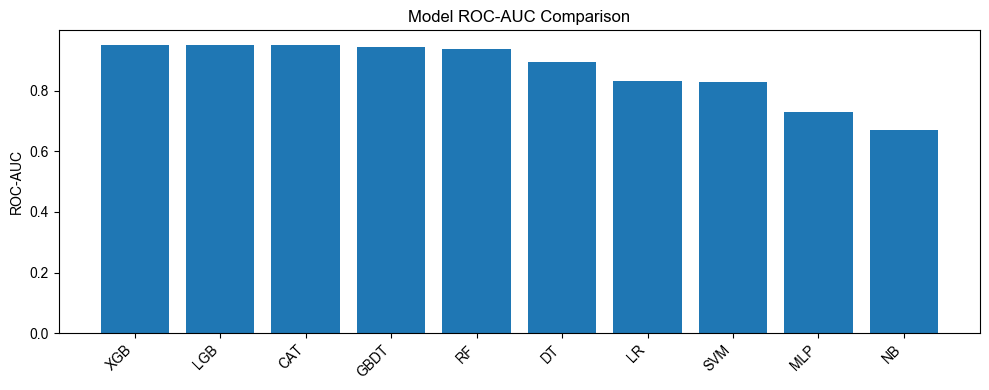

In [64]:
# 简单柱状图：ROC-AUC
plt.figure(figsize=(10, 4))
plt.bar(df_metrics['Model'], df_metrics['ROC_AUC'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model ROC-AUC Comparison')
plt.tight_layout()
save_exp_figure('model_auc_bar.png')
plt.show()
plt.close()

## <a id='toc11_2_'></a>[（已移除）Stacking/融合](#toc0_)

本版本已去除加权融合与 Stacking，仅保留“最优单模型选择”。


In [65]:
# Stacking / 融合已移除：本版本不再训练元模型。

# <a id='toc12_'></a>[提交文件](#toc0_)



In [66]:
# sub[LABEL] = (final_prob_test >= best_thr).astype(int)   # 也可换成 best_stack_pred
# sub.to_csv(SUBMISSION_OUT, index=False)
# print(f'>>> 提交文件已保存：{SUBMISSION_OUT}')

# <a id='toc13_'></a>[结果可视化](#toc0_)

正在绘制 ROC/PR 曲线...


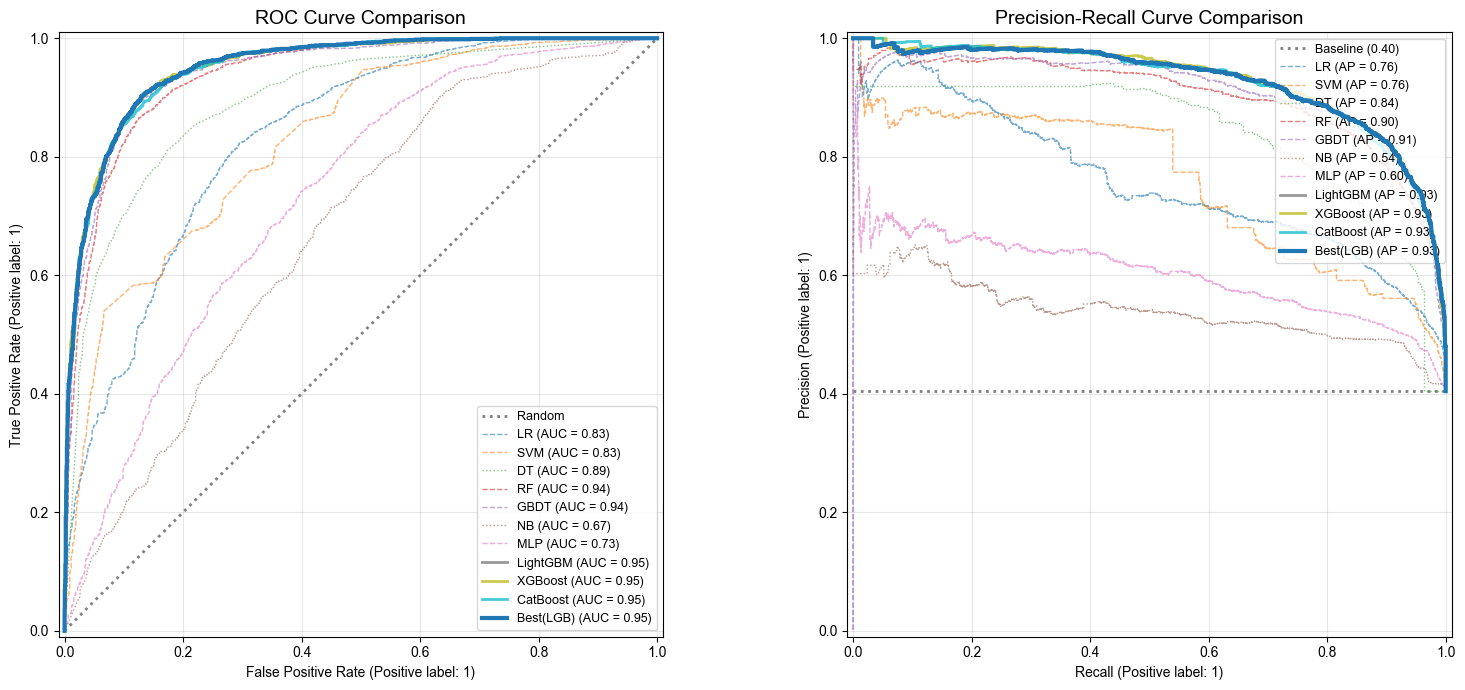

In [67]:
from utils import plot_roc_pr_curve

plot_data = [
    # --- 基础模型 (Sklearn) ---
    (oof_lr,   'LR',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_svm,  'SVM',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_dt,   'DT',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_rf,   'RF',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_gbdt, 'GBDT', {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_nb,   'NB',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_mlp,  'MLP',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    
    # --- 提升树模型 (Boosting) ---
    (oof_lgb,  'LightGBM', {'lw': 2, 'alpha': 0.8}),
    (oof_xgb,  'XGBoost',  {'lw': 2, 'alpha': 0.8}),
    (oof_cat,  'CatBoost', {'lw': 2, 'alpha': 0.8}),

    # --- 最佳单模型（无融合） ---
    (best_model_oof, f'Best({best_short})', {'lw': 3, 'alpha': 1.0, 'zorder': 10}),
    
    # --- 融合模型 (Ensemble) ---
]
plot_roc_pr_curve(train_y, plot_data)
save_paper_figure('roc_pr_all_models.png')

正在筛选最佳单模型...

>>> 最佳模型: 【LightGBM】
>>> 最佳 F1 : 0.8619
>>> 最佳阈值: 0.4190


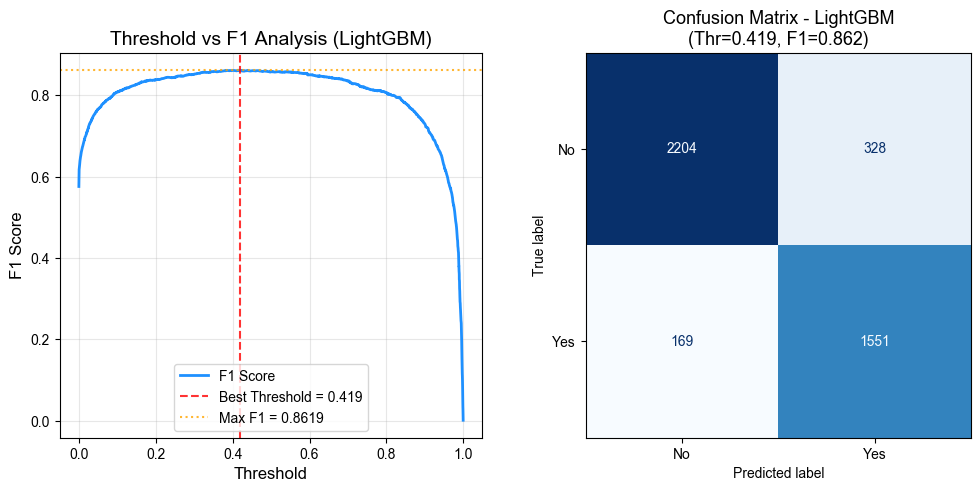

In [68]:
from utils import plot_best_model_analysis

# ======================================================
# 1. 筛选最好单模
# ======================================================
candidates = {
    'Logistic Regression': oof_lr,
    'SVM': oof_svm,
    'Decision Tree': oof_dt,
    'Random Forest': oof_rf,
    'GBDT': oof_gbdt,
    'Naive Bayes': oof_nb,
    'MLP': oof_mlp,
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat
}

best_model_name = None
best_model_oof = None
global_best_f1 = -1
global_best_thr = -1

print("正在筛选最佳单模型...")
for name, oof_pred in candidates.items():
    # 计算该模型下的最佳阈值和F1
    p, r, t = precision_recall_curve(train_y, oof_pred)
    f1_scores = 2 * (p * r) / (p + r + 1e-8)

    idx = np.argmax(f1_scores)
    current_max_f1 = f1_scores[idx]
    
    current_best_thr = t[idx] if idx < len(t) else t[-1]
    
    if current_max_f1 > global_best_f1:
        global_best_f1 = current_max_f1
        global_best_thr = current_best_thr
        best_model_name = name
        best_model_oof = oof_pred

print(f"\n>>> 最佳模型: 【{best_model_name}】")
print(f">>> 最佳 F1 : {global_best_f1:.4f}")
print(f">>> 最佳阈值: {global_best_thr:.4f}")

# ======================================================
# 绘制最佳单模型的 阈值-F1 曲线 和 混淆矩阵
# ======================================================
plot_best_model_analysis(
    train_y, best_model_name, best_model_oof, global_best_f1, global_best_thr,
    display_labels=label_map_int2str.values(),
)
save_exp_figure(f'threshold_f1_confusion_matrix_{best_model_name.replace(" ", "_")}')
plt.show()
plt.close()

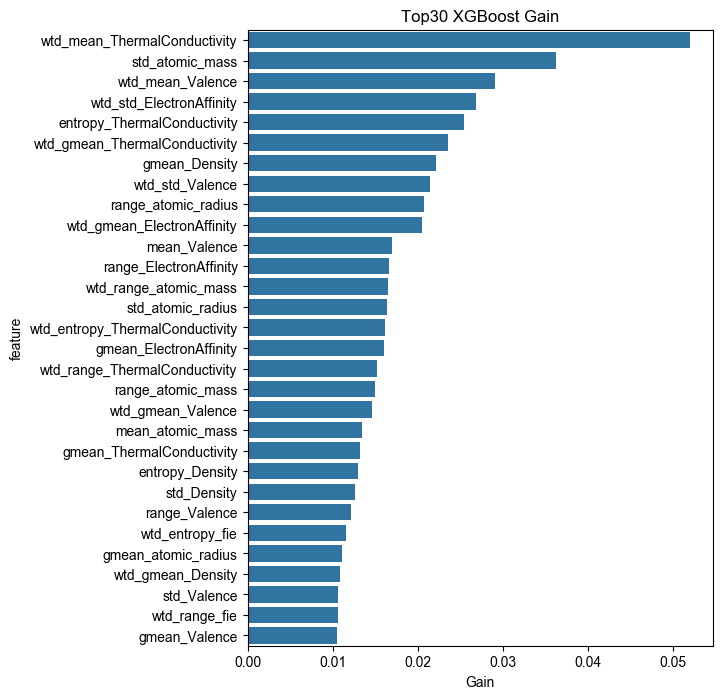

In [69]:
from utils import plot_feature_importance

feature_names = list(X_train.columns)
# ========== 特征重要性（XGBoost示例） ==========
plot_feature_importance(model=m_xgb, feature_names=feature_names)
save_exp_figure('xgb_importance.png')

In [70]:
# ------------------------------------------------------------------
# SHAP 汇总（用融合模型代表）
# ------------------------------------------------------------------
print('>>> SHAP 解释性（融合模型代表）')
explainer = shap.TreeExplainer(m_xgb)          # 可用 m_xgb / m_lgb / m_cat
sample_num = 2000  # 建议保留 sample_num 以防止全量数据导致内存溢出
X_subset = X_train.iloc[:sample_num]
shap_values_raw = explainer.shap_values(X_subset)  # 计算 SHAP 值

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_value = explainer.expected_value[1]
    else:
        expected_value = explainer.expected_value
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value

>>> SHAP 解释性（融合模型代表）


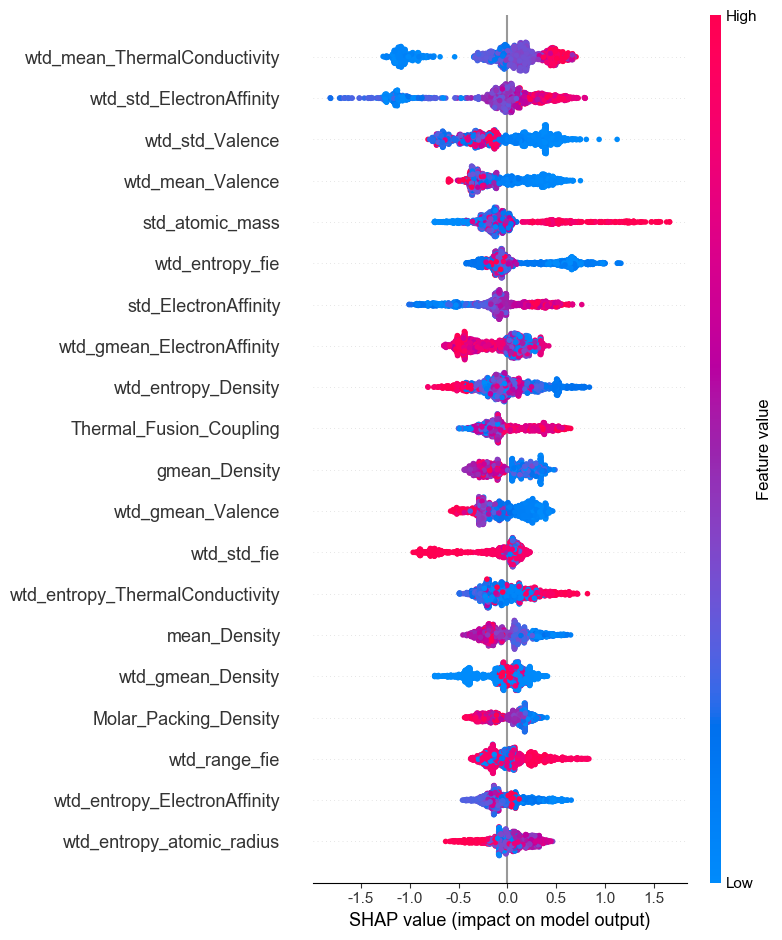

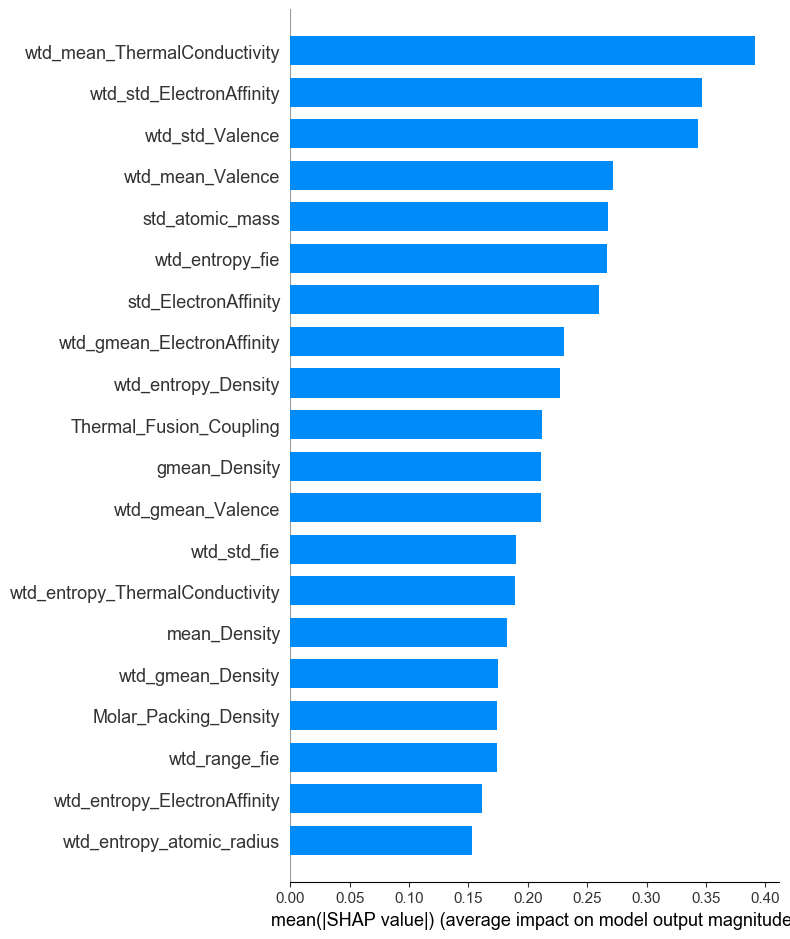

In [71]:
# === 1. 摘要图 (Summary Plot) ===
plt.figure()
shap.summary_plot(shap_values, X_subset, feature_names=feature_names, show=False)
plt.tight_layout()
# save_exp_figure("shap_summary.png", dpi=300)
save_paper_figure("fig4_shap_summary.png", dpi=300)
plt.show()
plt.close()

# === 摘要条形图 (Bar Plot) ===
plt.figure()
shap.summary_plot(shap_values, X_subset, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
# save_exp_figure("shap_bar.png", dpi=300)
save_paper_figure("fig3_shap_bar.png", dpi=300)
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

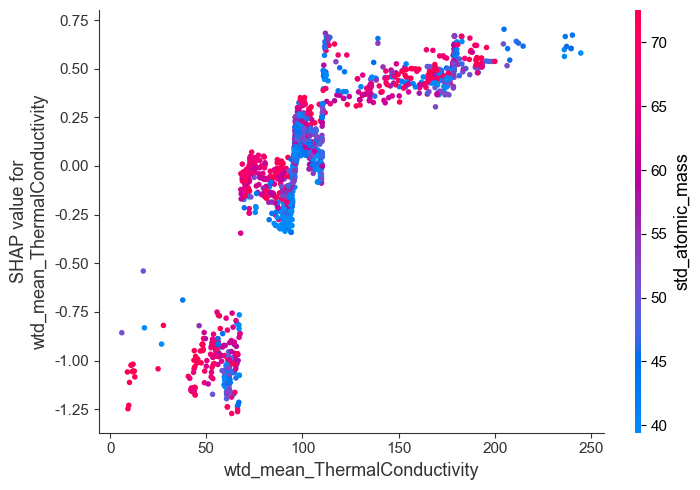

In [72]:
# === 2. SHAP 依赖图（最重要特征） ===
top_feat_idx = np.abs(shap_values).mean(0).argmax() 
plt.figure()
shap.dependence_plot(top_feat_idx, shap_values, X_subset, feature_names=feature_names, show=False)
plt.tight_layout()
# save_exp_figure("shap_dependence.png", dpi=300)
save_paper_figure("fig5_shap_dependence.png", dpi=300)
plt.show()
plt.close()

In [73]:
X_train.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

<Figure size 640x480 with 0 Axes>

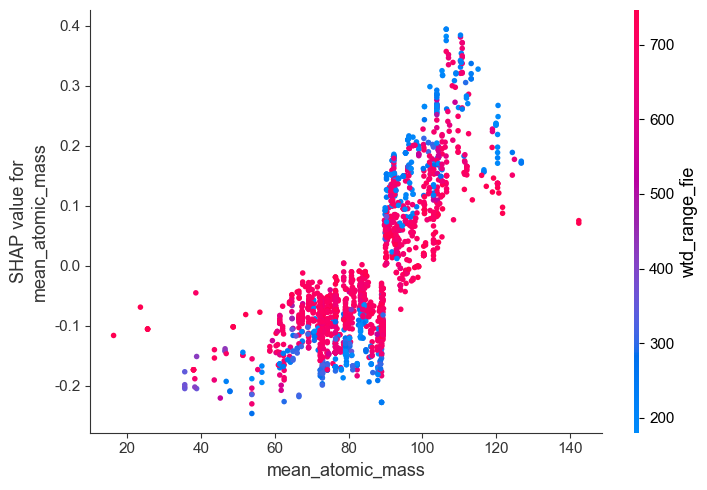

<Figure size 640x480 with 0 Axes>

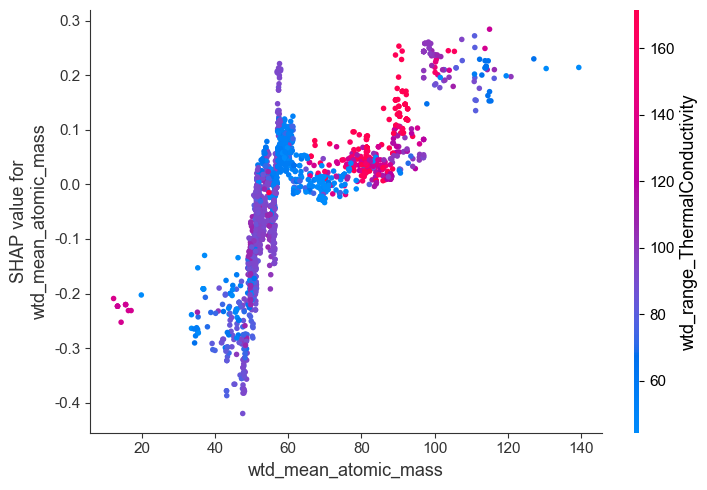

<Figure size 640x480 with 0 Axes>

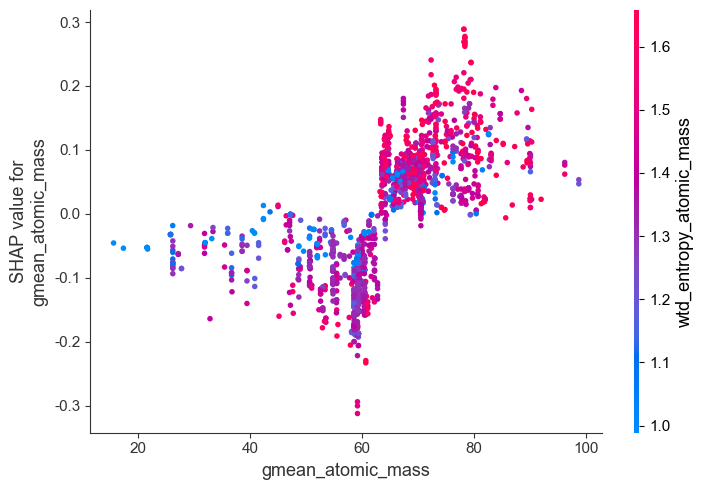

In [75]:
# === 2b. SHAP 依赖图（指定特征：Interest Rate / Annual Income） ===
specified_features = ['gmean_atomic_mass', 'mean_atomic_mass', 'wtd_mean_atomic_mass']
specifieidxd_idx = [i for i, _ in enumerate(feature_names) if _ in specified_features]
for fidx, fname in zip(specifieidxd_idx, specified_features):
    plt.figure()
    shap.dependence_plot(
        fidx, shap_values, X_subset,
        feature_names=feature_names, show=False
    )
    plt.tight_layout()
    save_exp_figure(f"shap_dependence_{fname}.png", dpi=300, bbox_inches='tight')
    save_paper_figure(f"shap_dependence_{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

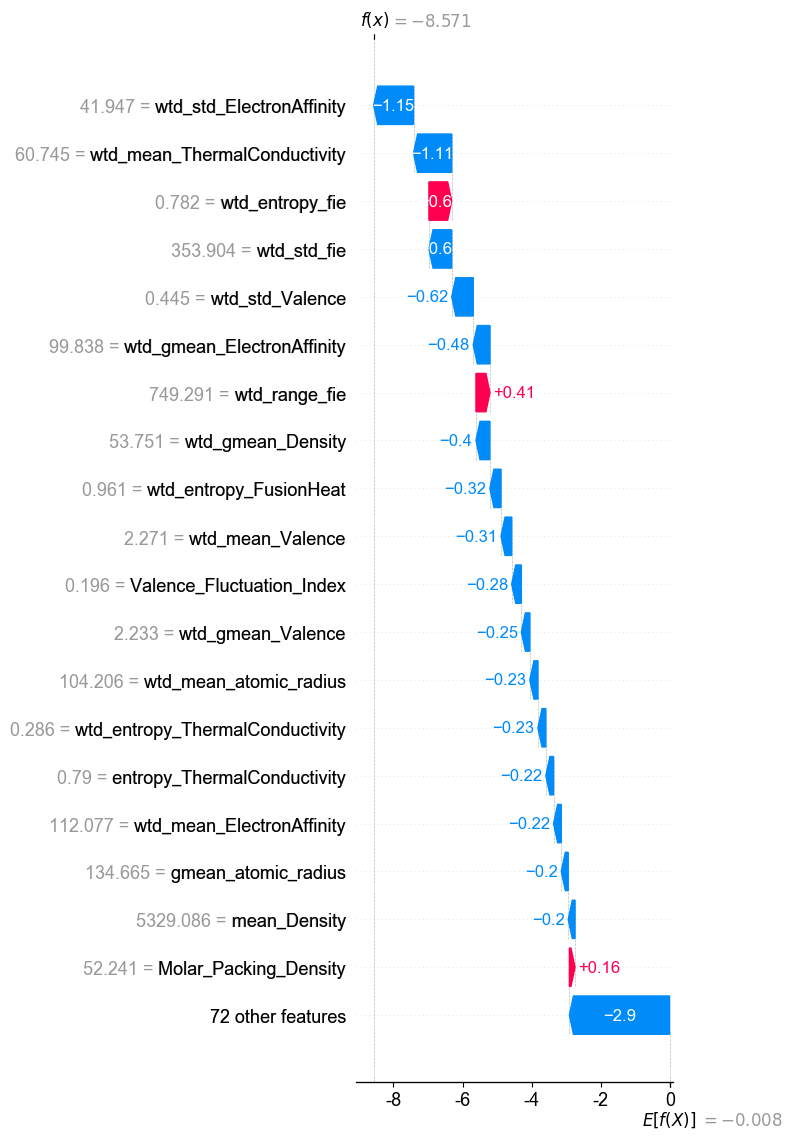

In [76]:
# === 3. SHAP 瀑布图（单样本示例） ===
sample_idx = 0 
plt.figure()
# 使用 Explanation 对象适配新版绘图接口
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=expected_value,
        data=X_subset.iloc[sample_idx],
        feature_names=feature_names
    ),
    max_display=20, show=False
)
plt.tight_layout()
save_exp_figure("shap_waterfall.png", dpi=300)
plt.show()
plt.close()